In [1]:
data <- read.csv("sdg7_renewable_energy_percent.csv")
head(data)
summary(data)

,Year,Renewable_Energy_Percent
,<int>,<dbl>
1,1990,12.75
2,1991,12.26
3,1992,13.91
4,1993,15.69
5,1994,13.52
6,1995,13.99


      Year      Renewable_Energy_Percent
 Min.   :1990   Min.   :12.26           
 1st Qu.:1998   1st Qu.:15.98           
 Median :2006   Median :18.19           
 Mean   :2006   Mean   :19.30           
 3rd Qu.:2014   3rd Qu.:22.46           
 Max.   :2022   Max.   :29.31           

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


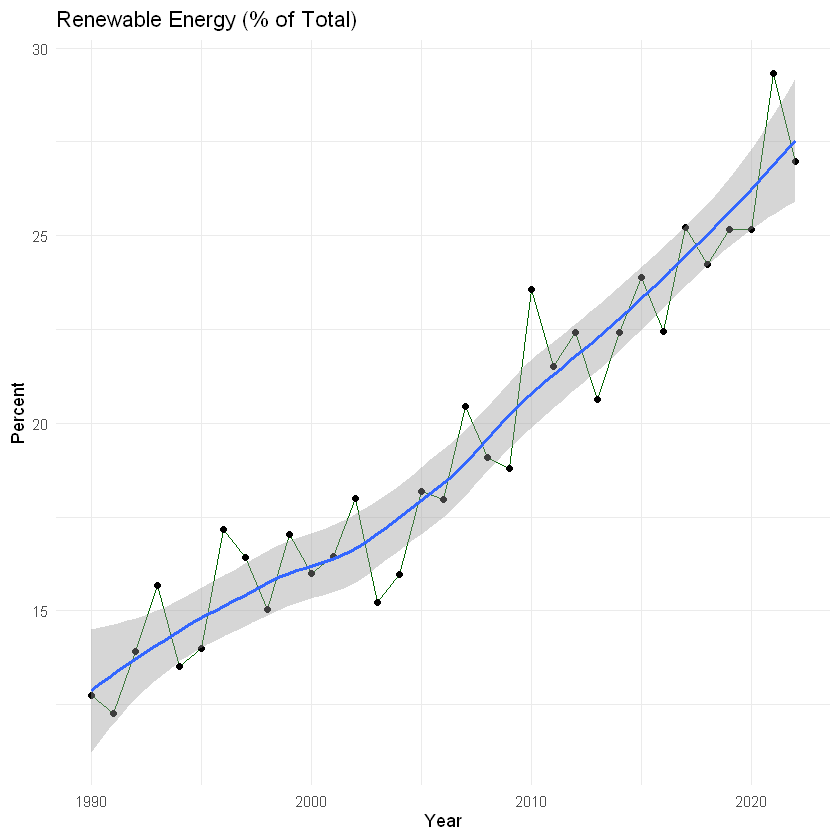

In [5]:
library(ggplot2)

ggplot(data, aes(x = Year, y = Renewable_Energy_Percent)) +
  geom_line(color = "darkgreen") +
  geom_point() + geom_smooth() +
  labs(title = "Renewable Energy (% of Total)", y = "Percent", x = "Year") +
  theme_minimal()

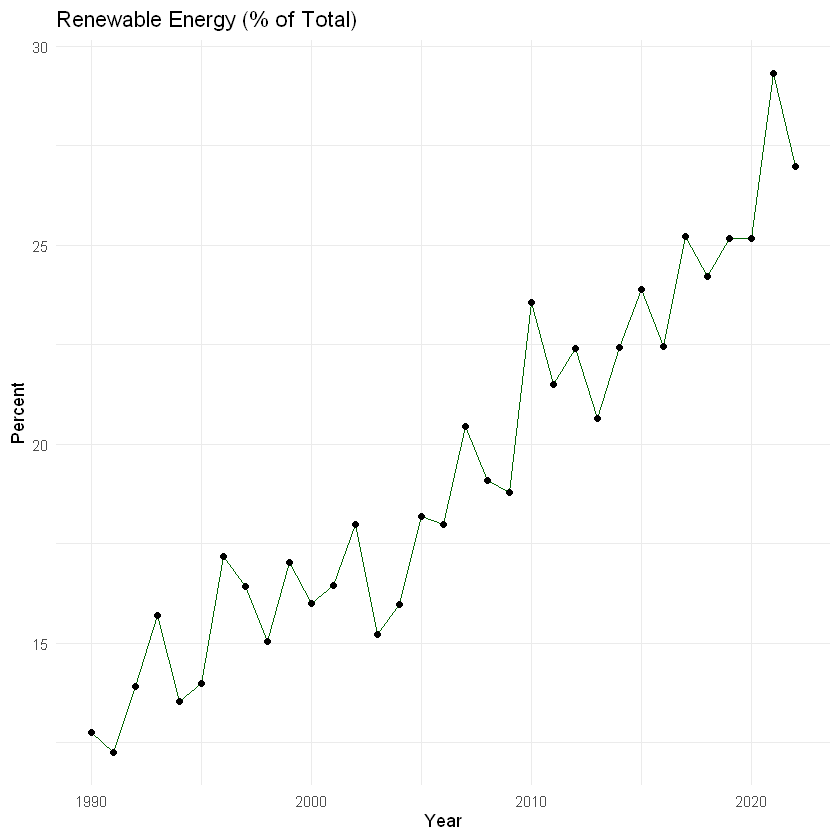

In [6]:
library(ggplot2)

ggplot(data, aes(x = Year, y = Renewable_Energy_Percent)) +
  geom_line(color = "darkgreen") +
  geom_point() + 
  labs(title = "Renewable Energy (% of Total)", y = "Percent", x = "Year") +
  theme_minimal()
     

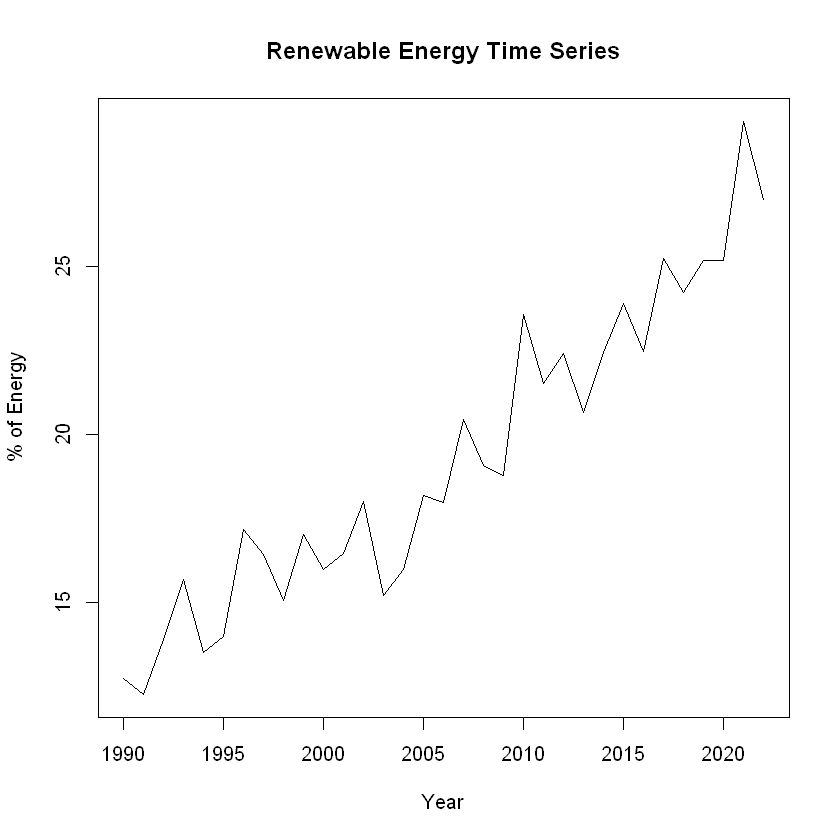

In [8]:
par(bg = "White")
ts_data <- ts(data$Renewable_Energy_Percent, start = 1990, frequency = 1)
plot(ts_data, main = "Renewable Energy Time Series", ylab = "% of Energy", xlab = "Year")

In [12]:
library(tseries)

adf.test(ts_data)  # Augmented Dickey-Fuller Test


	Augmented Dickey-Fuller Test

data:  ts_data
Dickey-Fuller = -1.4986, Lag order = 3, p-value = 0.7668
alternative hypothesis: stationary


In [11]:
library(forecast)

model <- auto.arima(ts_data)
summary(model)

Series: ts_data 
ARIMA(0,1,1) with drift 

Coefficients:
          ma1   drift
      -0.8272  0.4483
s.e.   0.1485  0.0524

sigma^2 = 2.142:  log likelihood = -57.14
AIC=120.28   AICc=121.14   BIC=124.68

Training set error measures:
                      ME     RMSE      MAE        MPE    MAPE     MASE
Training set -0.02003848 1.395607 1.056973 -0.8469776 5.71951 0.646343
                   ACF1
Training set -0.0750061

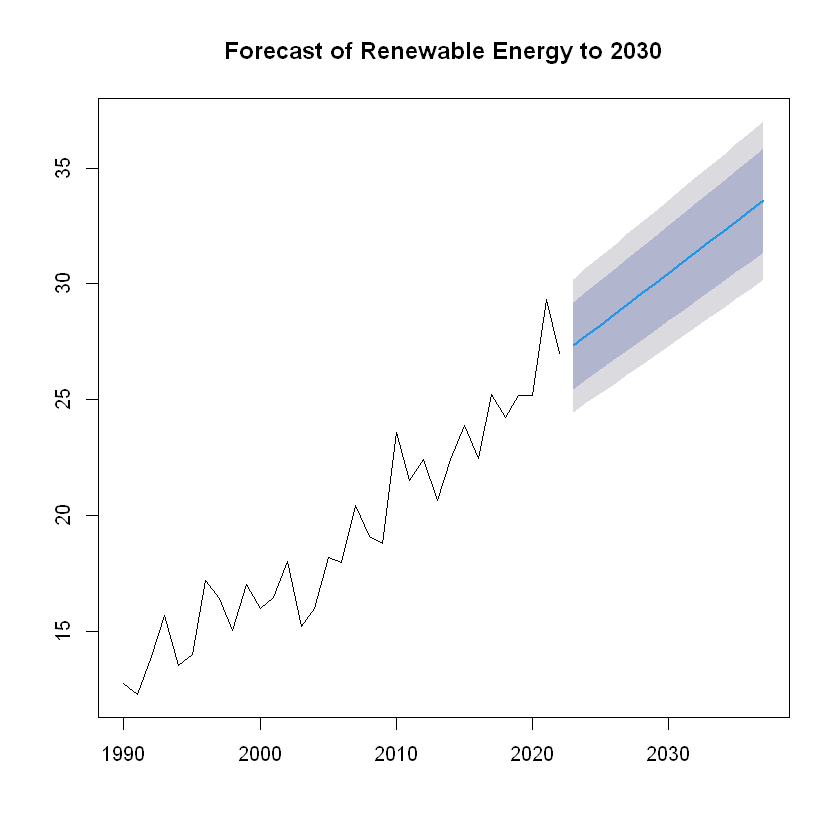


	Ljung-Box test

data:  Residuals from ARIMA(0,1,1) with drift
Q* = 3.6527, df = 6, p-value = 0.7236

Model df: 1.   Total lags used: 7



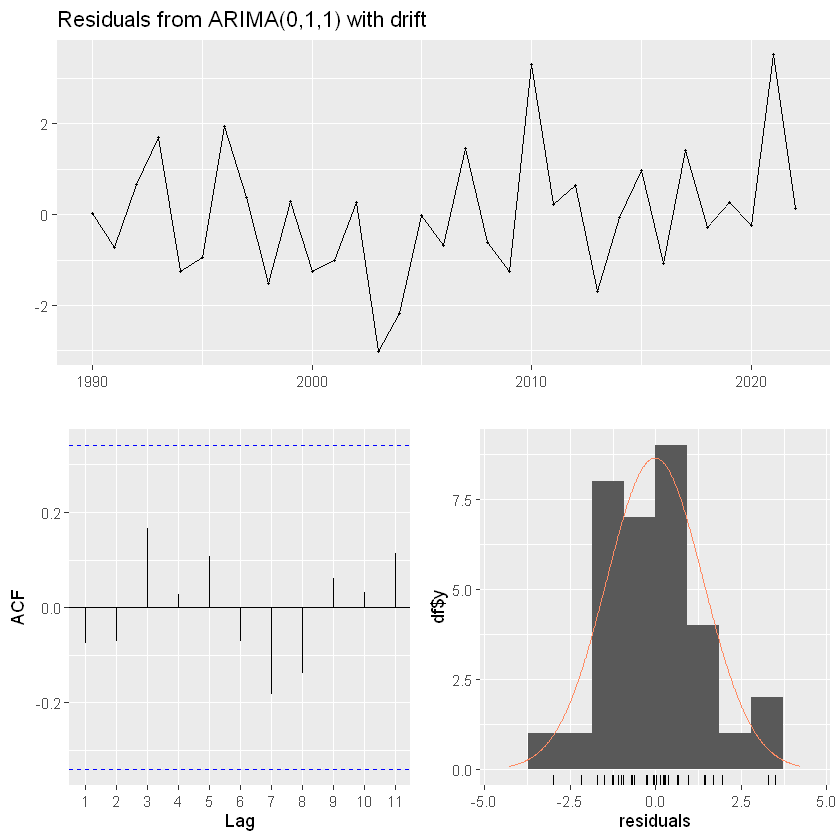

In [ ]:
par(bg = "White")
forecasted <- forecast(model, h = 15)  # 2023 to 2037
plot(forecasted, main = "Forecast of Renewable Energy to 2037")
checkresiduals(model)

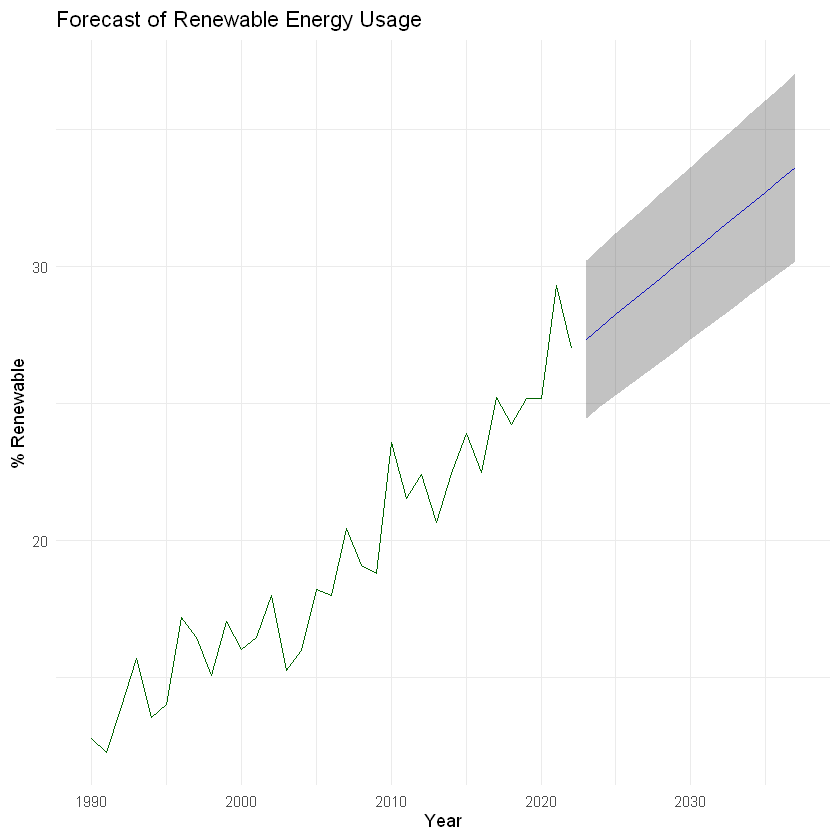

In [26]:
# Convert forecast to data frame for plotting
forecast_df <- data.frame(
  Year = 2023:2037,
  Forecast = as.numeric(forecasted$mean),
  Lower = as.numeric(forecasted$lower[,2]),
  Upper = as.numeric(forecasted$upper[,2])
)

ggplot() +
  geom_line(data = data, aes(x = Year, y = Renewable_Energy_Percent), color = "darkgreen") +
  geom_line(data = forecast_df, aes(x = Year, y = Forecast), color = "blue") +
  geom_ribbon(data = forecast_df, aes(x = Year, ymin = Lower, ymax = Upper), alpha = 0.3) +
  labs(title = "Forecast of Renewable Energy Usage", y = "% Renewable", x = "Year") +
  theme_minimal()